In [1]:
# Load LeafletSC 
import LeafletSC
import os
import pandas as pd 
import sys

from LeafletSC.clustering.find_intron_clusters import visualize_local_events
from LeafletSC.beta_binomial_mix.modeling import *
from LeafletSC.beta_binomial_mix.calculate_cellstate_consistency import *
from LeafletSC.clustering.load_cluster_data import *

In [2]:
# set device to cuda if available 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# set float type to torch.float to save memory
float_type = { 
    "device" : device, 
    "dtype" : torch.float, 
}

cpu


In [3]:
# Define path that contains the model input files and append it (input can be a folder with one .h5 file per cell_type for example or one file)
model_input_file="/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/all_tissues/TS_Leaflet_model_input.h5"

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data(
     input_file = model_input_file, max_intron_count=10000, remove_singletons=True, has_genes="yes")

# Note: the input to load_cluster_data may be either a single file (input_file=X) or a folder of files (input_folder=X) as indicated above. 

# add cluster information to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# generate torch tensors for sparse data representation 
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

# simplify columns 
simple_data_human = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

print("The number of junctions is: ", len(junction_ids_conversion))
print("The number of intron clusters observed is: ", len(junction_ids_conversion.Cluster.unique()))
print("The number of genes is: ", len(junction_ids_conversion.gene_id.unique()))
print("The number of cells is: ", len(simple_data_human.cell_id_index.unique()))

Reading in data from folder ...
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  34867
Number of junctions after removing singletons:  34867
The number of unique cell types in the data is:  26065
The number of unique cells in the data is:  26065
The number of unique junctions in the data is:  34868
The maximum junction count was initially:  651560
105
The maximum junction count is now:  9926
The number of junctions in the data is:  34301
The number of cells in the data is:  25999
The number of cell types in the data is:  25999
The number of cells going into training data is:
25999
25999


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/LeafletSC/clustering/load_cluster_data.py:47: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount).to_sparse_csr()


In [7]:
# simple_data_human fix cell_type column to keep only .str.split("/")[7]
# make a table with unique cell_type 
cell_types = simple_data_human["cell_type"].unique()
# turn into dataframe 
cell_types = pd.DataFrame(cell_types, columns=["cell_type"])
# split cell_type column
cell_types = cell_types["cell_type"].str.split("/", expand=True)
# keep only the last column
cell_types = cell_types[7]
# append original cell_type and name new column cell_type_clean
cell_types = cell_types.to_frame(name="cell_type_clean")
cell_types["cell_type"] = simple_data_human["cell_type"].unique()
# merge with simple_data_human
simple_data_human = simple_data_human.merge(cell_types, on="cell_type")
# remove cell_type column and rename cell_type_clean as cell_type
simple_data_human = simple_data_human.drop(columns=["cell_type"])
simple_data_human = simple_data_human.rename(columns={"cell_type_clean": "cell_type"})
simple_data_human

,cell_type_clean,cell_type
0,Lung,/gpfs/commons/projects/CZI-tabula-sapiens/SS2_...
1,Lung,/gpfs/commons/projects/CZI-tabula-sapiens/SS2_...
2,Lung,/gpfs/commons/projects/CZI-tabula-sapiens/SS2_...
3,Lung,/gpfs/commons/projects/CZI-tabula-sapiens/SS2_...
4,Lung,/gpfs/commons/projects/CZI-tabula-sapiens/SS2_...
...,...,...
25994,Pancreas,/gpfs/commons/projects/CZI-tabula-sapiens/SS2_...
25995,Pancreas,/gpfs/commons/projects/CZI-tabula-sapiens/SS2_...
25996,Pancreas,/gpfs/commons/projects/CZI-tabula-sapiens/SS2_...
25997,Pancreas,/gpfs/commons/projects/CZI-tabula-sapiens/SS2_...


In [10]:
# add cell_type to cell_ids_conversion
cell_ids_conversion = cell_ids_conversion.merge(cell_types, on="cell_type")
# do the same remove old cell_type column and rename cell_type_clean
cell_ids_conversion = cell_ids_conversion.drop(columns=["cell_type"])
cell_ids_conversion = cell_ids_conversion.rename(columns={"cell_type_clean": "cell_type"})
cell_ids_conversion

,cell_id_index,cell_id,cell_type
0,0,B107809_A15_S135.homo.gencode.v30.ERCC.chrM_/g...,Lung
1,1,B107809_A18_S138.homo.gencode.v30.ERCC.chrM_/g...,Lung
2,2,B107809_A5_S125.homo.gencode.v30.ERCC.chrM_/gp...,Lung
3,3,B107809_A6_S126.homo.gencode.v30.ERCC.chrM_/gp...,Lung
4,4,B107809_A8_S128.homo.gencode.v30.ERCC.chrM_/gp...,Lung
...,...,...,...
25994,25994,TSP9_Pancreas_exocrine_SS2_B134188_B133826_Imm...,Pancreas
25995,25995,TSP9_Pancreas_exocrine_SS2_B134188_B133826_Imm...,Pancreas
25996,25996,TSP9_Pancreas_exocrine_SS2_B134188_B133826_Imm...,Pancreas
25997,25997,TSP9_Pancreas_exocrine_SS2_B134188_B133826_Imm...,Pancreas


### Run Binomial mixture model!

In [11]:
torch.manual_seed(42)
np.random.seed(42)

# Let's try to first set K to 10 
K = 20

# Define model priors
hypers = {
    "eta" : 1./K, 
    "alpha_prior" : 1., 
    "pi_prior" : 1.
}

print(hypers["eta"])

0.05


In [12]:
num_trials = 2 # let's run the model 10 times with different initializations
num_iters = 100 # max number of iterations for CAVI 
print("The K used is: ", K)
results = [calculate_CAVI(K, my_data, float_type, hypers, num_iterations = num_iters) 
           for t in range(num_trials) ]

The K used is:  20
Initialize VI params
Initializing variational parameters with N = 25999 cells and J = 34301 junctions
Running CAVI with unknown cell types (not predefined)
z and theta will be updated!
Got the initial ELBO ^
The tolerance is set to  0.001
Updating z and thetaAVI iteration #  1
Updating z and thetaVI iteration #  2
Updating z and thetaVI iteration #  3
Updating z and thetaVI iteration #  4
Updating z and thetaVI iteration #  5
Updating z and thetaVI iteration #  6
Updating z and thetaVI iteration #  7
Updating z and thetaVI iteration #  8
Updating z and thetaVI iteration #  9
Updating z and thetaVI iteration #  10
Updating z and thetaVI iteration #  11
Updating z and thetaVI iteration #  12
Updating z and thetaVI iteration #  13
Updating z and thetaVI iteration #  14
Updating z and thetaVI iteration #  15
Updating z and thetaVI iteration #  16
Updating z and thetaVI iteration #  17
ELBO converged @ -698835904.0 CAVI iteration # 17 complete
ELBO converged @ -698835904.

In [13]:
results[1][3].shape

torch.Size([25999, 20])

In [14]:
sum_matrices = consensus_clustering(results)

# normalize by number of trials
normalized_matrix = sum_matrices / sum_matrices.max() # taking the sum_matrix and dividing by the max value in the matrix

# get distance metric 
distance_matrix = 1 - normalized_matrix

Got all cells and their assignments based on PHI_f in each trial!
Got a cell by cell matrix for each trial indicating whether cells were coassigned
Getting sum of matrices across all iterations


In [15]:
sum_matrices

array([[2., 0., 0., ..., 0., 0., 0.],
       [0., 2., 0., ..., 0., 0., 0.],
       [0., 0., 2., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 2., 1., 0.],
       [0., 0., 0., ..., 1., 2., 0.],
       [0., 0., 0., ..., 0., 0., 2.]])

(array([6.09858028e+08, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 6.43355060e+07, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.75446700e+06]),
 array([0.  , 0.04, 0.08, 0.12, 0.16, 0.2 , 0.24, 0.28, 0.32, 0.36, 0.4 ,
        0.44, 0.48, 

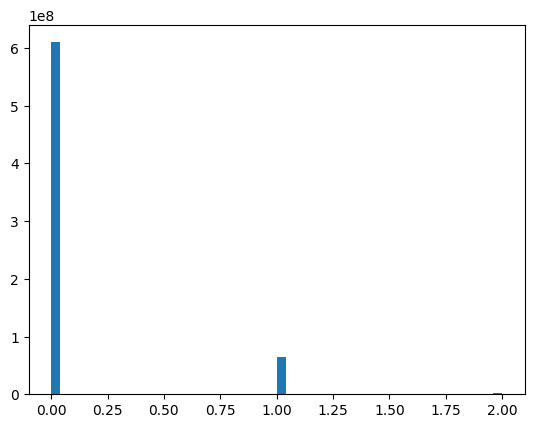

In [16]:
# plot histogram of values in sum_matrices
plt.hist(sum_matrices.flatten(), bins=50)

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


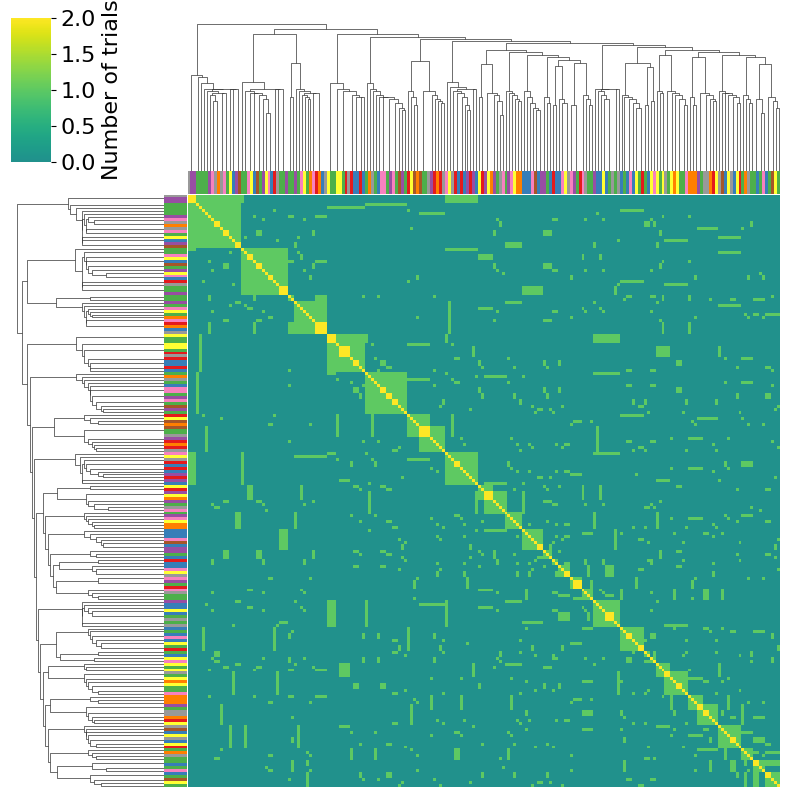

In [17]:
# plot heatmap 

num_samples = 200
samp_indices = np.random.choice(cell_ids_conversion.shape[0], num_samples, replace=False)
cell_types_heatmap = cell_ids_conversion.iloc[samp_indices]

color_palette = sns.color_palette("Set1", n_colors=len(cell_types_heatmap['cell_type'].unique()))

# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_types_heatmap['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_types_heatmap.cell_type.values

cell_type_colors = dict(zip(unique_cell_types, colors))

# Convert cell types to corresponding colors for rows and columns
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]
col_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

cluster = sns.clustermap(
    data=sum_matrices[samp_indices,:][:,samp_indices],
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    xticklabels=False,
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    col_colors=col_colors,   # Apply column colors
        cbar_kws={'label': 'Number of trials'} # Split label over two lines here
    )

cluster.cax.set_ylabel('Number of trials', size=16)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(16)

plt.show()

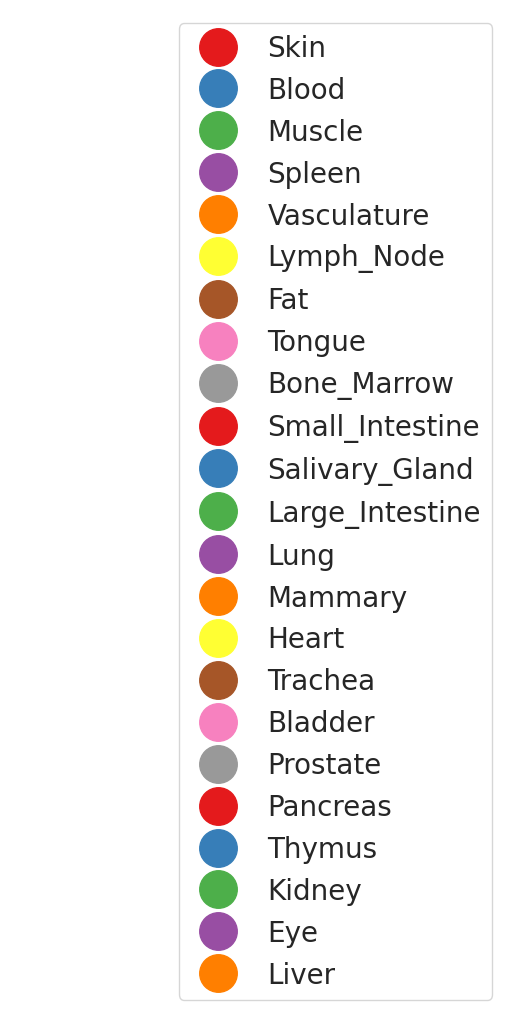

In [18]:
sns.set_style("white")

# Create the legend
for cell_type, color in cell_type_colors.items():
    plt.plot([], [], 'o', label=cell_type, color=color, markersize=27)  # Use 'o' to show the colors clearly

plt.legend(fontsize=20)
plt.axis('off')  # Turn off axis
plt.show()

### Evaluate the learned posteriors

The trial with the highest ELBO was 1


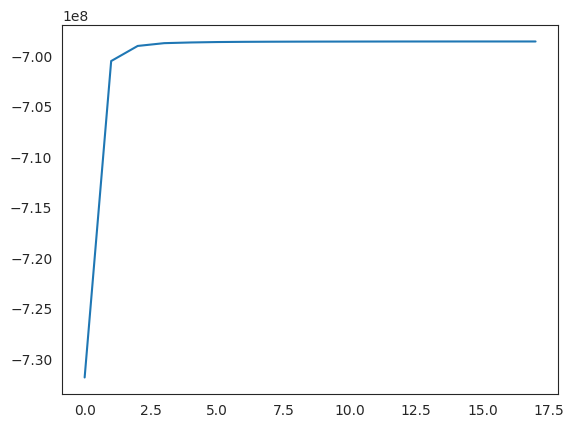

In [19]:
best = np.argmax([ g[-1][-1] for g in results ]) # final ELBO
print(f"The trial with the highest ELBO was {best}")
ALPHA_f, PI_f, GAMMA_f, PHI_f, elbos_all = results[best]
elbos_all = np.array(elbos_all)
plt.plot(elbos_all[1:]); plt.show()

In [20]:
PHI_f_plot = pd.DataFrame(PHI_f.cpu().numpy())
PHI_f_plot['cell_id'] = cell_ids_conversion["cell_type"].to_numpy()

(array([4.88424e+05, 9.70000e+02, 7.34000e+02, 6.68000e+02, 7.27000e+02,
        6.15000e+02, 4.09000e+02, 2.85000e+02, 2.10000e+02, 1.52000e+02,
        1.09000e+02, 1.04000e+02, 9.60000e+01, 6.40000e+01, 5.70000e+01,
        5.00000e+01, 4.50000e+01, 5.40000e+01, 4.20000e+01, 3.70000e+01,
        3.30000e+01, 3.60000e+01, 2.30000e+01, 2.90000e+01, 2.20000e+01,
        2.30000e+01, 1.80000e+01, 1.90000e+01, 9.00000e+00, 2.50000e+01,
        1.40000e+01, 1.10000e+01, 2.10000e+01, 1.60000e+01, 1.40000e+01,
        1.60000e+01, 1.10000e+01, 1.10000e+01, 1.20000e+01, 1.40000e+01,
        5.00000e+00, 1.30000e+01, 9.00000e+00, 1.00000e+01, 8.00000e+00,
        8.00000e+00, 1.20000e+01, 8.00000e+00, 7.00000e+00, 1.30000e+01,
        7.00000e+00, 1.20000e+01, 7.00000e+00, 5.00000e+00, 9.00000e+00,
        1.00000e+01, 6.00000e+00, 6.00000e+00, 7.00000e+00, 6.00000e+00,
        9.00000e+00, 7.00000e+00, 5.00000e+00, 1.30000e+01, 6.00000e+00,
        8.00000e+00, 4.00000e+00, 1.00000e+01, 2.00

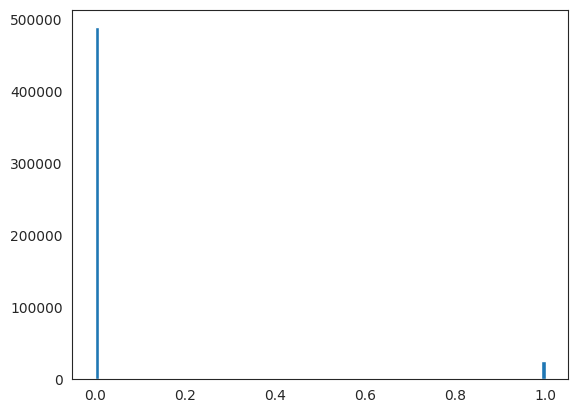

In [21]:
np.array(PHI_f.flatten())
# make histogram of the cell type proportions
plt.hist(np.array(PHI_f.flatten()), bins=100)

In [22]:
# How much is each cell state is used globally 

# Calculate the total sum of the tensor values
total_sum = torch.sum(GAMMA_f)

# Calculate the percentages
percentages = (GAMMA_f / total_sum) 
print(percentages)

# Convert the tensor to a dataframe 
GAMMA_f_plot = pd.DataFrame(percentages.cpu().numpy())
# Give it a colname called theta 
GAMMA_f_plot.columns = ["theta"]
GAMMA_f_plot["cell_state"] = GAMMA_f_plot.index
GAMMA_f_plot.sort_values(by="theta", ascending=False, inplace=True)
GAMMA_f_plot["new_cell_state"] = np.arange(GAMMA_f_plot.shape[0])

sorted_cell_states = GAMMA_f_plot["new_cell_state"].astype(str)

# rename cell_state to be from 0 to K-1 based on order in sorted_cell_states
GAMMA_f_plot

tensor([0.0522, 0.0561, 0.0519, 0.0513, 0.0471, 0.0474, 0.0495, 0.0527, 0.0556,
        0.0478, 0.0463, 0.0420, 0.0522, 0.0526, 0.0483, 0.0493, 0.0524, 0.0490,
        0.0460, 0.0505])


,theta,cell_state,new_cell_state
1,0.056065,1,0
8,0.055612,8,1
7,0.052666,7,2
13,0.052576,13,3
16,0.052396,16,4
12,0.052226,12,5
0,0.052171,0,6
2,0.051907,2,7
3,0.051262,3,8
19,0.050458,19,9


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/scratch/ipykernel_37372/1628281085.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="new_cell_state", y="theta", data=GAMMA_f_plot, palette=color_mapping)
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


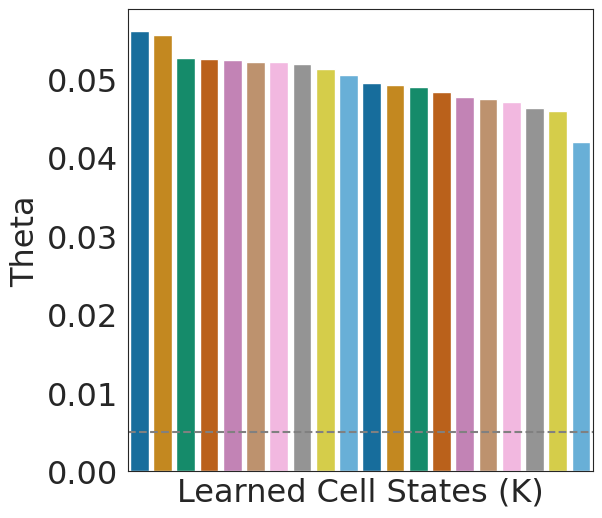

In [23]:
GAMMA_f_plot["new_cell_state"] = pd.Categorical(sorted_cell_states, sorted_cell_states.unique())
GAMMA_f_plot = GAMMA_f_plot.sort_values(by='new_cell_state')

# Create a color mapping for each unique cellassignment
unique_states = GAMMA_f_plot['new_cell_state'].unique()
palette = sns.color_palette("colorblind", len(unique_states))
color_mapping = dict(zip(unique_states, palette))

# Make barplot using sns
plt.figure(figsize=(6, 6))
sns.barplot(x="new_cell_state", y="theta", data=GAMMA_f_plot, palette=color_mapping)
plt.axhline(0.005, ls='--', color='grey')

# Make Y label say Theta and increase font of all labels and ticks
plt.ylabel("Theta", fontsize=23)
plt.xlabel("Learned Cell States (K)", fontsize=23)
plt.xticks([])
plt.yticks(fontsize=23)
plt.show()

In [24]:
cell_types_summary=cell_ids_conversion['cell_type'].value_counts()
cell_types_summary=pd.DataFrame(cell_types_summary)
cell_types_summary.reset_index(inplace=True)
cell_types_summary.columns=['cell_type','count']

# get percentage of each cell type in the data 
cell_types_summary['percentage']=cell_types_summary['count']/cell_types_summary['count'].sum()
cell_types_summary.sort_values(by='percentage',ascending=False,inplace=True)
print(cell_types_summary)

          cell_type  count  percentage
0            Muscle   4950    0.190392
1        Lymph_Node   2381    0.091580
2       Bone_Marrow   2227    0.085657
3            Spleen   2114    0.081311
4             Blood   1909    0.073426
5            Tongue   1385    0.053271
6              Lung   1378    0.053002
7           Bladder    924    0.035540
8       Vasculature    847    0.032578
9              Skin    840    0.032309
10   Salivary_Gland    830    0.031924
11         Pancreas    761    0.029270
12              Fat    630    0.024232
13         Prostate    626    0.024078
14           Thymus    599    0.023039
15  Small_Intestine    598    0.023001
16          Mammary    569    0.021885
17          Trachea    468    0.018001
18  Large_Intestine    431    0.016578
19              Eye    398    0.015308
20           Kidney    370    0.014231
21           Uterus    286    0.011000
22            Heart    272    0.010462
23            Liver    206    0.007923


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, 'Muscle'),
  Text(1, 0, 'Lymph_Node'),
  Text(2, 0, 'Bone_Marrow'),
  Text(3, 0, 'Spleen'),
  Text(4, 0, 'Blood'),
  Text(5, 0, 'Tongue'),
  Text(6, 0, 'Lung'),
  Text(7, 0, 'Bladder'),
  Text(8, 0, 'Vasculature'),
  Text(9, 0, 'Skin'),
  Text(10, 0, 'Salivary_Gland'),
  Text(11, 0, 'Pancreas'),
  Text(12, 0, 'Fat'),
  Text(13, 0, 'Prostate'),
  Text(14, 0, 'Thymus'),
  Text(15, 0, 'Small_Intestine'),
  Text(16, 0, 'Mammary'),
  Text(17, 0, 'Trachea'),
  Text(18, 0, 'Large_Intestine'),
  Text(19, 0, 'Eye'),
  Text(20, 0, 'Kidney'),
  Text(21, 0, 'Uterus'),
  Text(22, 0, 'Heart'),
  Text(23, 0, 'Liver')])

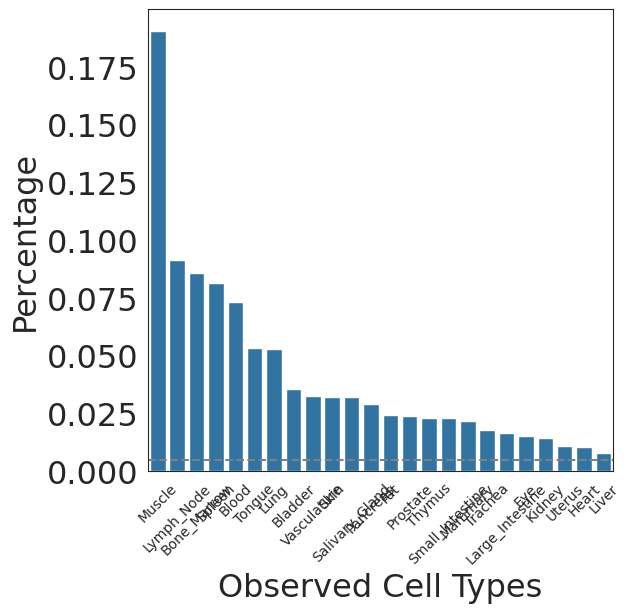

In [25]:
# Create the barplot using the cell_type_colors palette
plt.figure(figsize=(6, 6))
sns.barplot(x="cell_type", y="percentage", data=cell_types_summary)
plt.axhline(0.005, ls='--', color='grey')
plt.ylabel("Percentage", fontsize=23)
plt.xlabel("Observed Cell Types", fontsize=23)
plt.yticks(fontsize=23)
# rotate xaxis labels 45 degrees
plt.xticks(rotation=45)

In [26]:
# convert PHI_f to a dataframe and add a column with cell ID and cell type 
PHI_f = pd.DataFrame(PHI_f)

# Keep only cell states defined above GAMMA_f_plot.index.values
PHI_f = PHI_f.loc[:, GAMMA_f_plot.index.values]
PHI_f

,1,8,7,13,16,12,0,2,3,19,6,15,17,14,9,5,4,10,18,11
0,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
2,2.164204e-10,3.672804e-20,4.050435e-22,5.791496e-08,6.898149e-07,0.002871,0.064809,3.563933e-06,0.328798,0.002068,1.685340e-21,1.704313e-08,1.655119e-08,2.435169e-07,2.162024e-12,0.044676,2.760634e-19,1.899673e-33,8.248903e-26,5.567735e-01
3,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25994,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25995,6.023853e-05,1.172978e-06,9.977319e-01,7.194639e-04,1.345535e-04,0.000090,0.000220,6.959876e-08,0.000694,0.000149,3.856612e-05,1.331884e-05,5.850067e-05,8.888883e-09,9.651010e-07,0.000005,3.334983e-06,2.868501e-09,7.845983e-05,5.772077e-07
25996,2.326687e-01,1.400009e-01,4.543496e-03,1.165103e-02,1.683008e-02,0.014396,0.048842,3.019403e-02,0.033792,0.001559,3.025761e-03,5.984084e-02,2.858272e-02,3.376540e-01,1.882923e-04,0.007432,1.114384e-06,7.224542e-03,5.963523e-04,2.097708e-02
25997,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [27]:
# Add "CellState" to each column 
PHI_f.columns = ["CellState_" + str(i+1) for i in range(PHI_f.shape[1])]
PHI_f['cell_id'] = cell_ids_conversion.cell_id.values
PHI_f['cell_type'] = cell_ids_conversion.cell_type.values

In [28]:
PHI_f_melt = pd.melt(PHI_f, id_vars=['cell_id', 'cell_type'], value_vars=PHI_f.columns[:-2])

# for each cell, choose cell state with highest probability
PHI_f_melt = PHI_f_melt.sort_values(by=['cell_id', 'value'], ascending=False).drop_duplicates(subset=['cell_id'])
PHI_f_melt.head()

,cell_id,cell_type,variable,value
129994,TSP9_Pancreas_exocrine_SS2_B134188_B133826_Imm...,Pancreas,CellState_5,1.000000
363984,TSP9_Pancreas_exocrine_SS2_B134188_B133826_Imm...,Pancreas,CellState_14,1.000000
363983,TSP9_Pancreas_exocrine_SS2_B134188_B133826_Imm...,Pancreas,CellState_14,0.337654
77993,TSP9_Pancreas_exocrine_SS2_B134188_B133826_Imm...,Pancreas,CellState_3,0.997732
467977,TSP9_Pancreas_exocrine_SS2_B134188_B133826_Imm...,Pancreas,CellState_18,1.000000


In [29]:
cell_ids_conversion.cell_type.value_counts()

cell_type
Muscle             4950
Lymph_Node         2381
Bone_Marrow        2227
Spleen             2114
Blood              1909
Tongue             1385
Lung               1378
Bladder             924
Vasculature         847
Skin                840
Salivary_Gland      830
Pancreas            761
Fat                 630
Prostate            626
Thymus              599
Small_Intestine     598
Mammary             569
Trachea             468
Large_Intestine     431
Eye                 398
Kidney              370
Uterus              286
Heart               272
Liver               206
Name: count, dtype: int64

In [30]:
PHI_f

,CellState_1,CellState_2,CellState_3,CellState_4,CellState_5,CellState_6,CellState_7,CellState_8,CellState_9,CellState_10,...,CellState_13,CellState_14,CellState_15,CellState_16,CellState_17,CellState_18,CellState_19,CellState_20,cell_id,cell_type
0,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,B107809_A15_S135.homo.gencode.v30.ERCC.chrM_/g...,Lung
1,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,B107809_A18_S138.homo.gencode.v30.ERCC.chrM_/g...,Lung
2,2.164204e-10,3.672804e-20,4.050435e-22,5.791496e-08,6.898149e-07,0.002871,0.064809,3.563933e-06,0.328798,0.002068,...,1.655119e-08,2.435169e-07,2.162024e-12,0.044676,2.760634e-19,1.899673e-33,8.248903e-26,5.567735e-01,B107809_A5_S125.homo.gencode.v30.ERCC.chrM_/gp...,Lung
3,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,B107809_A6_S126.homo.gencode.v30.ERCC.chrM_/gp...,Lung
4,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,1.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,B107809_A8_S128.homo.gencode.v30.ERCC.chrM_/gp...,Lung
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25994,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,TSP9_Pancreas_exocrine_SS2_B134188_B133826_Imm...,Pancreas
25995,6.023853e-05,1.172978e-06,9.977319e-01,7.194639e-04,1.345535e-04,0.000090,0.000220,6.959876e-08,0.000694,0.000149,...,5.850067e-05,8.888883e-09,9.651010e-07,0.000005,3.334983e-06,2.868501e-09,7.845983e-05,5.772077e-07,TSP9_Pancreas_exocrine_SS2_B134188_B133826_Imm...,Pancreas
25996,2.326687e-01,1.400009e-01,4.543496e-03,1.165103e-02,1.683008e-02,0.014396,0.048842,3.019403e-02,0.033792,0.001559,...,2.858272e-02,3.376540e-01,1.882923e-04,0.007432,1.114384e-06,7.224542e-03,5.963523e-04,2.097708e-02,TSP9_Pancreas_exocrine_SS2_B134188_B133826_Imm...,Pancreas
25997,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000e+00,1.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,TSP9_Pancreas_exocrine_SS2_B134188_B133826_Imm...,Pancreas


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


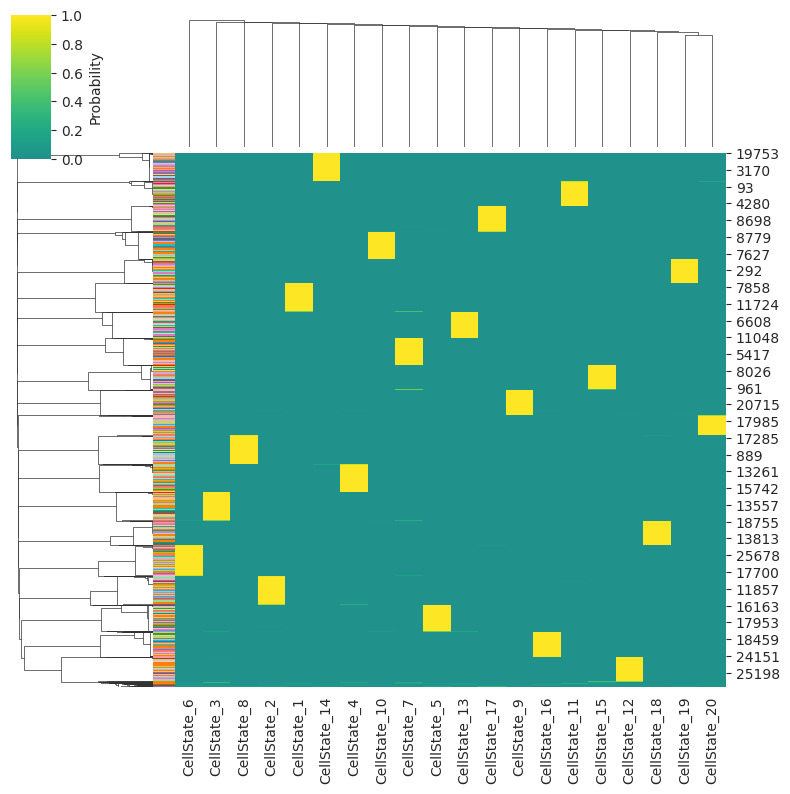

In [35]:
# add cell type colorbar to sns.clustermap of PHI_f
# randomly sample 5000 cells 
samp_indices = np.random.choice(PHI_f.shape[0], 5000, replace=False)
PHI_f_samp = PHI_f.iloc[samp_indices]
#PHI_f_samp = PHI_f[PHI_f["cell_type"].isin(["Bladder", "Pancreas"])]
cell_types = PHI_f_samp['cell_type']
unique_cell_types = cell_types.unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('tab20', n_colors=num_unique_types)  # You can use any color palette
cell_type_colors = dict(zip(unique_cell_types, colors))

sns.clustermap(PHI_f_samp.iloc[:, :-2], cmap="viridis", figsize=(8, 8), center=0, cbar_kws={'label': 'Probability'}, row_colors=[cell_type_colors[cell_type] for cell_type in cell_types])

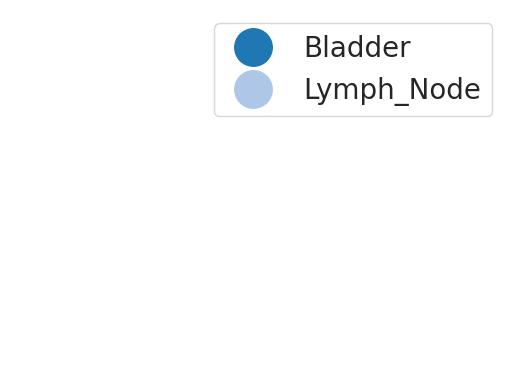

In [32]:
# show which colour was used for each cell_type
for cell_type, color in cell_type_colors.items():
    plt.plot([], [], 'o', label=cell_type, color=color, markersize=27, linestyle='None')  # Use 'o' to show the colors clearly
plt.legend(fontsize=20)
plt.axis('off')  # Turn off axis
plt.show()